<a href="https://colab.research.google.com/github/anishjagota/undergrad_ml_assignments/blob/main/01_data_analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers
## Part 1 — Data Analyst (EDA)

We study the cleaned air-fryer brand-year dataset before estimating any model. The cleaned file keeps the top 10 brands from 2019-2023 and recomputes `brand_share` so that shares sum to 1 within each year inside the cleaned name-brand market.

In [1]:
import numpy as np                # Numerical analysis
import pandas as pd                # Dataframes and basic statistics
import matplotlib.pyplot as plt    # Basic plotting
import seaborn as sns              # Advanced plotting


## Outline

1. Verify the dataset
2. Plots over time by brand
3. Product characteristics
4. Market description


# 1. Verify the dataset

In [3]:
df = pd.read_csv('air_fryers_clean_brand_year.csv')

print(df.shape)
df.head()


(50, 15)


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [4]:
print('Brands:', sorted(df['brand'].unique()))
print('Years :', sorted(df['year'].unique()))
print('\nbrand_share sums by year:')
df.groupby('year')['brand_share'].sum().round(6)


Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

brand_share sums by year:


,brand_share
year,
2019,1.0
2020,1.0
2021,1.0
2022,1.0
2023,1.0


**Answer.** The dataset contains exactly 10 brands (`chefman, cosori, cuisinart, dash, gowise usa, instant_pot, ninja, nuwave, oster, ultrean`) and 5 years (2019-2023), giving 50 brand-year rows. `brand_share` sums to 1 in every year, so the cleaned market is well defined.

# 2. Plots over time by brand

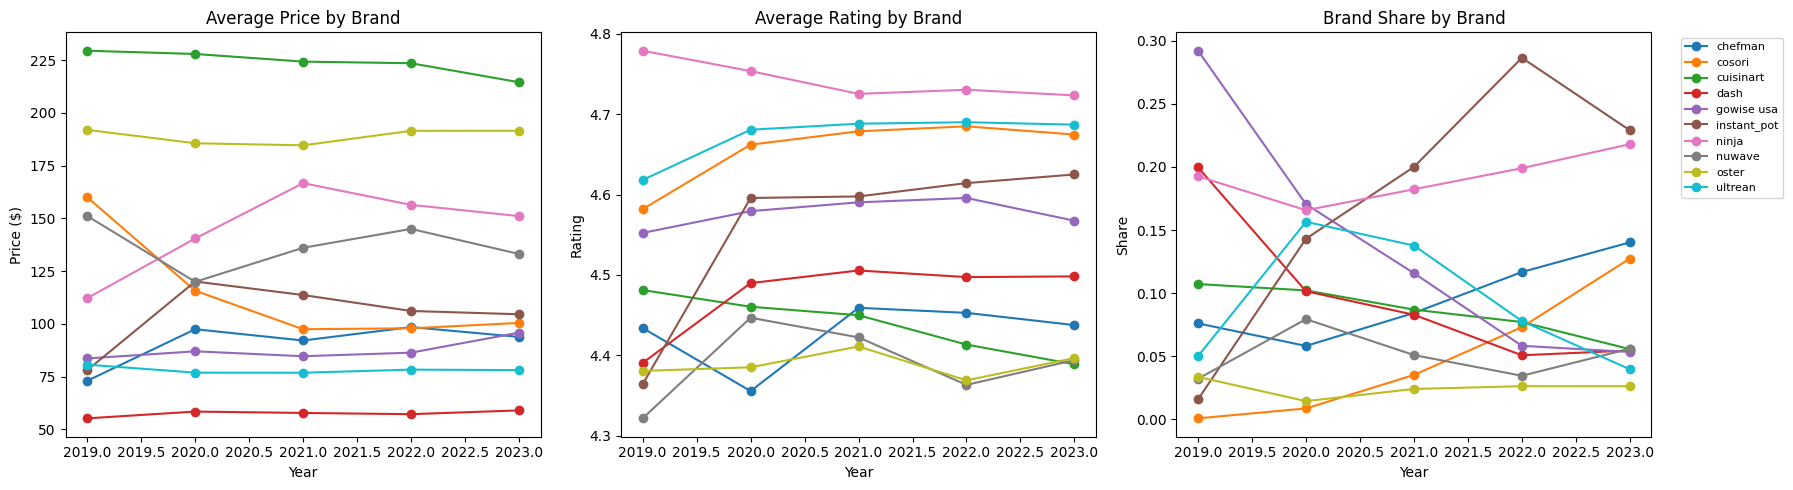

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for brand, sub in df.groupby('brand'):
    sub = sub.sort_values('year')
    axes[0].plot(sub['year'], sub['avg_price'],   marker='o', label=brand)
    axes[1].plot(sub['year'], sub['avg_rating'],  marker='o', label=brand)
    axes[2].plot(sub['year'], sub['brand_share'], marker='o', label=brand)

axes[0].set_title('Average Price by Brand');  axes[0].set_xlabel('Year'); axes[0].set_ylabel('Price ($)')
axes[1].set_title('Average Rating by Brand'); axes[1].set_xlabel('Year'); axes[1].set_ylabel('Rating')
axes[2].set_title('Brand Share by Brand');    axes[2].set_xlabel('Year'); axes[2].set_ylabel('Share')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


**What the plots show:**

- **Price.** Cuisinart sits at the top of the price range (~\$215-230). Oster is second-most expensive (~\$180-190). Most brands cluster in the \$75-150 range, and Dash is the cheapest (~\$55-60). Prices are fairly stable across the 5 years.
- **Rating.** Ratings are tightly bunched between roughly 4.35 and 4.75. Ninja has the highest average rating, followed by Ultrean and Cosori. Nuwave, Oster, and Cuisinart sit at the bottom. Ratings drift slightly upward over time.
- **Share.** Shares are dynamic. GoWise USA collapses from ~29% in 2019 to ~5% in 2023. Instant Pot rises from ~3% to ~23%. Ninja grows from ~19% to ~22%. Cosori comes from essentially zero in 2019 to ~13% in 2023. Prices and ratings move much less than shares, so the reshuffling appears driven by something other than price or quality.

### Brand-level averages (mean over 2019-2023)


In [6]:
summary = df.loc[:, ['brand','avg_price','avg_rating','brand_share']].groupby('brand').mean().round(3)
summary.sort_values('brand_share', ascending=False)


,avg_price,avg_rating,brand_share
brand,,,
ninja,145.343,4.742,0.192
instant_pot,104.461,4.559,0.175
gowise usa,87.455,4.577,0.138
dash,57.479,4.476,0.098
chefman,90.938,4.428,0.095
ultrean,78.115,4.673,0.092
cuisinart,223.947,4.439,0.086
nuwave,137.024,4.390,0.051
cosori,114.268,4.656,0.049


# 3. Product characteristics

In [7]:
feature_cols = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share',
]

# Market-wide prevalence of each feature, averaged across all brand-year cells:
df.loc[:, feature_cols].mean().round(3)


,0
compact_share,0.980
dual_basket_share,0.002
oven_style_share,0.563
rotisserie_share,0.071
window_share,0.037


In [8]:
# Specialization: average characteristic share by brand
brand_features = df.loc[:, ['brand'] + feature_cols].groupby('brand').mean()
brand_features.round(2)


,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.96,0.01,0.60,0.37,0.36
cosori,1.00,0.00,0.03,0.02,0.00
cuisinart,1.00,0.00,0.91,0.00,0.00
dash,1.00,0.00,0.89,0.00,0.00
gowise usa,1.00,0.00,0.18,0.18,0.00
instant_pot,0.86,0.00,0.67,0.10,0.00
ninja,0.99,0.00,0.10,0.00,0.00
nuwave,1.00,0.01,0.54,0.03,0.00
oster,1.00,0.00,0.86,0.00,0.00


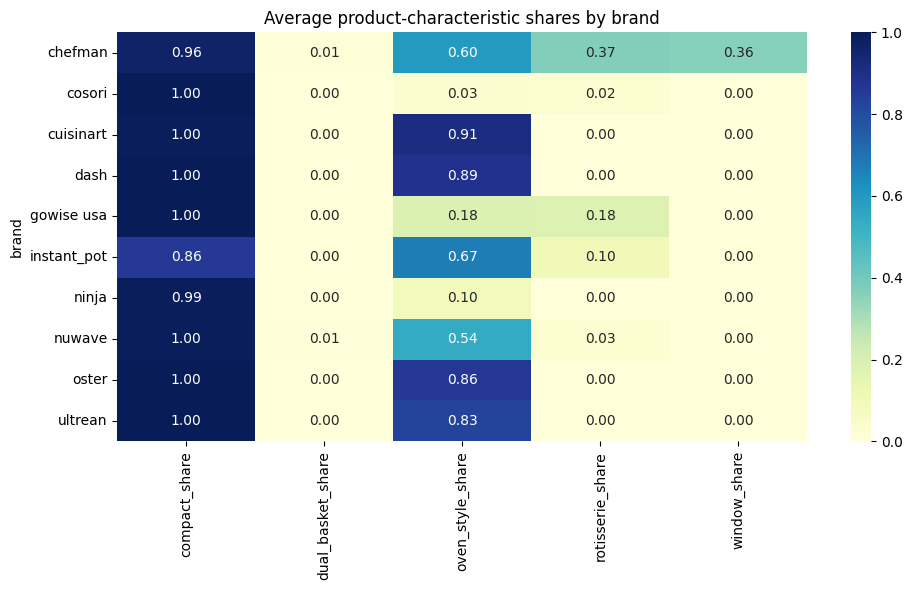

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(brand_features, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax)
ax.set_title('Average product-characteristic shares by brand')
plt.tight_layout()
plt.show()


**Answer.**

- **Common features.** `compact_share` is essentially saturated — every brand has products that are >85% compact, and most are 100%. `oven_style_share` is also widespread (>50% for chefman, cuisinart, dash, instant_pot, nuwave, oster, ultrean), though some brands (cosori, ninja, gowise usa) lean toward basket-style, non-oven products.
- **Rare features.** `dual_basket_share` is almost entirely absent — only chefman and nuwave register any dual-basket presence, and both at about 1%. `window_share` is rare and concentrated almost entirely at chefman (about 36%). `rotisserie_share` shows up mainly at chefman (about 37%), gowise usa (about 18%), and instant_pot (approximately 10%).
- **Specialization.** Yes, brands specialize. Chefman is the clearest outlier: it carries window and rotisserie features that essentially no other brand offers. Cuisinart, dash, oster, and ultrean are simple oven-style brands. Cosori and ninja position themselves as compact basket-style fryers. Instant Pot and gowise usa fall in between.

# 4. Market description

The cleaned air-fryer market is dominated by a handful of mid-priced brands. **Ninja** ( approximately 19% average share, \$145 average price, highest average rating at 4.74) and **Instant Pot** (approximately 17% share, \$104 price) are the two largest players, followed by **GoWise USA** ( approximately 14%) and **Chefman** (approximately 10%). **Cuisinart** (\$224 price) and **Oster** (\$189 price) anchor the premium end of the market but command only modest shares (about 9% and 3% respectively), suggesting that high price by itself does not buy market share in this category. **Dash** is the discount brand at about \$57 average price and a respectable 10% share.

The market is **not** stable over time. The big story between 2019 and 2023 is the collapse of GoWise USA — from about 29% share in 2019 to 5% in 2023 — and the simultaneous rise of Instant Pot (from 3% to 23%) and Cosori (essentially absent in 2019, 13% by 2023). Ninja, the largest brand by the end of the window, grows steadily across the period. Prices and ratings move much less than shares, so the reshuffling appears to be driven by something other than direct price or quality changes — possibly product-line refreshes, marketing shifts, or distribution.